<div style="background:#c62828;padding:28px 24px;border-radius:8px;margin-bottom:16px;">
<h1 style="color:white;font-size:22px;font-weight:700;margin:0 0 8px;">Deep Q-Learning: From Q-Learning to Neural Networks — A Tutorial</h1>
<p style="color:rgba(255,255,255,0.85);font-size:14px;margin:0;">A structured extension of the Q-Learning tutorial. Covers why Q-Learning breaks down on complex problems and how Deep Q-Networks solve it.</p>
</div>

| Section | Topic |
|---------|-------|
| **1** | Why Q-Learning has limits |
| **2** | Neural Networks — a quick intro |
| **3** | The DQN Architecture |
| **4** | Experience Replay |
| **5** | The Target Network |
| **6** | The Full DQN Algorithm |
| **7** | Full Python Code |

> **Prerequisite:** This tutorial assumes you have completed the Q-Learning tutorial and are familiar with: agent, environment, state, action, reward, Q-Table, Bellman equation, and ε-greedy policy.


In [ ]:
import numpy as np
import random
from collections import deque
print("Libraries loaded.")


Libraries loaded.


<div style="background:#c62828;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">1</span><span style="font-size:16px;font-weight:600;color:white;">Why Q-Learning Has Limits</span></div>


## Section 1 — Why Q-Learning Has Limits

In the Q-Learning tutorial, the agent navigated a 5×5 grid — 25 states, 4 actions, a Q-Table with 100 entries.

Now consider a real-world problem. In the Atari game *Breakout*, the state is an 84×84 pixel screen.
That gives roughly **10^67,000 possible states** — more than atoms in the observable universe.

A Q-Table cannot store a row for every possible state. It would be impossibly large, and most states would
never be visited during training, so their values would never be updated.


In [ ]:
display(HTML('''<div style="background:#fce4ec;border-left:4px solid #c62828;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#c62828">Important:</strong> Q-Tables work only when the number of states is small and discrete. Real environments — video games, robotics, financial markets — have state spaces that are either enormous or continuous.</div>'''))

In [ ]:
# Comparing the scale of different RL environments
environments = [
    ("GridWorld (Q-Learning)", "5×5 grid",      25,           "Q-Table: 100 entries — FEASIBLE"),
    ("Taxi-v3",               "500 states",     500,          "Q-Table: 3,000 entries — FEASIBLE"),
    ("Atari Breakout",        "84×84 pixels",   10**67000,    "Q-Table: IMPOSSIBLE"),
    ("Robotics arm",          "Continuous",     float('inf'), "Q-Table: IMPOSSIBLE"),
]
print(f"{'Environment':<26} {'State space':<16} {'Verdict'}")
print("-" * 65)
for name, space, n, verdict in environments:
    print(f"{name:<26} {space:<16} {verdict}")


Environment                State space      Verdict
-----------------------------------------------------------------
GridWorld (Q-Learning)     5×5 grid         Q-Table: 100 entries — FEASIBLE
Taxi-v3                    500 states       Q-Table: 3,000 entries — FEASIBLE
Atari Breakout             84×84 pixels     Q-Table: IMPOSSIBLE
Robotics arm               Continuous       Q-Table: IMPOSSIBLE


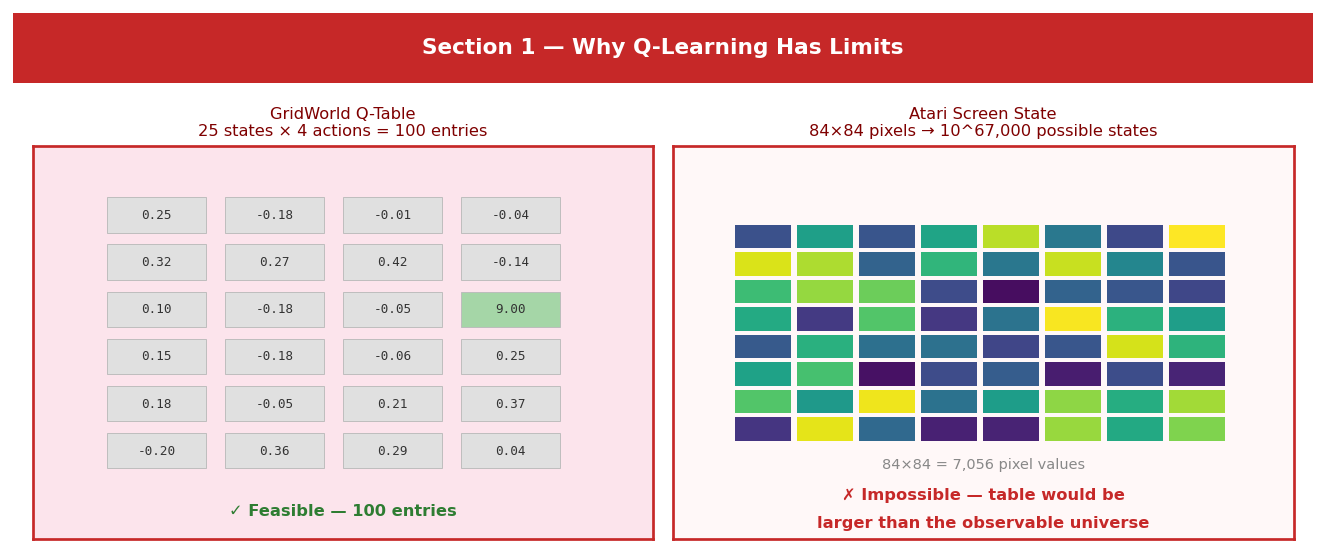

In [ ]:
display(Image(filename='dqn_assets/qtable_vs_dqn.png'))

### The solution: replace the table with a neural network

Instead of looking up Q-values in a table, we train a **neural network** to *approximate* them.
Given a state as input, the network outputs an estimated Q-value for every possible action.
This is called a **Deep Q-Network (DQN)**.


In [ ]:
display(HTML('''<div style="background:#e8f5e9;border-left:4px solid #2e7d32;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#2e7d32">Tip:</strong> A neural network <strong>generalises</strong>. If it learns that 'being near a wall is bad,' it applies that knowledge to any new wall position — even one never seen before. A Q-Table treats every state as completely independent.</div>'''))

In [ ]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> Q-Tables work only when the state space is small and discrete. Real-world environments have far too many states. <strong>Deep Q-Networks</strong> solve this by using a neural network to approximate Q-values, allowing the same Bellman update logic to scale to enormous state spaces.</div>'''))

<div style="background:#1565c0;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">2</span><span style="font-size:16px;font-weight:600;color:white;">Neural Networks — a Quick Introduction</span></div>


## Section 2 — Neural Networks — a Quick Introduction

A **neural network** is a mathematical function that transforms inputs into outputs.
It is made of layers of interconnected units called **neurons**.
Each connection has a **weight** — a number controlling how strongly one neuron influences the next.

Training means adjusting those weights so the outputs get closer to correct answers,
using an algorithm called **backpropagation** with an optimiser such as **Adam** or **SGD**.

### Structure of a neural network

- **Input layer** — receives the raw state (e.g. pixel values, position coordinates)
- **Hidden layers** — transform the input through learned weights and activation functions
- **Output layer** — produces one Q-value per action


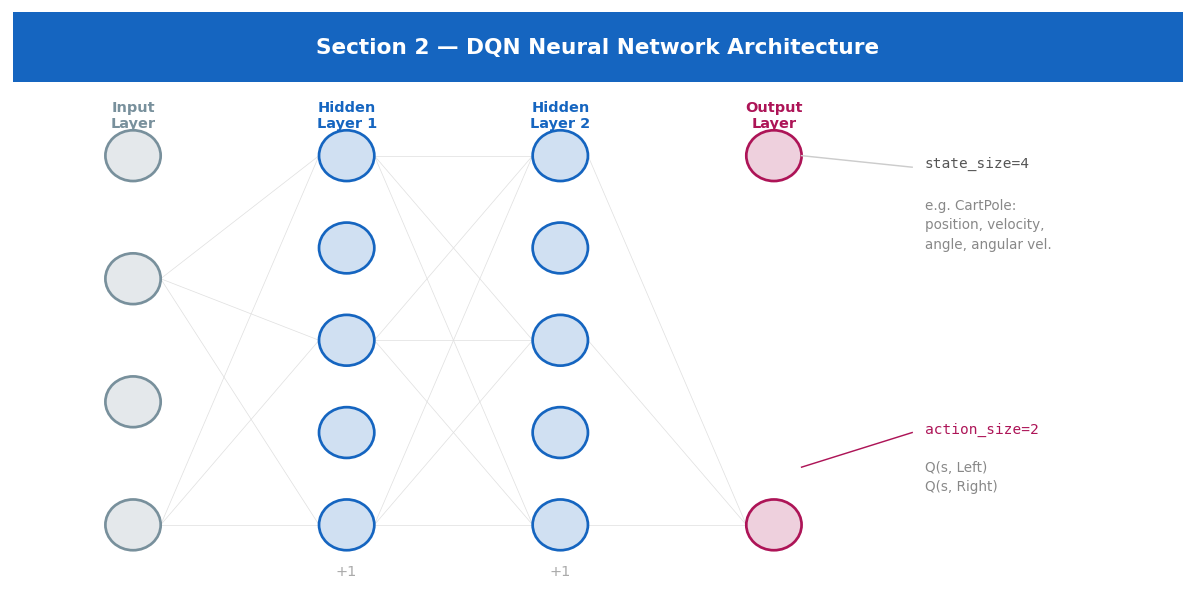

In [ ]:
display(Image(filename='dqn_assets/nn_architecture.png'))

In [ ]:
# A simple neural network for DQN — pseudocode
# Input:  state vector  (e.g. 4 numbers: position, velocity, angle, angular velocity)
# Output: Q-value for each action  (e.g. 2 values: Left, Right)

class QNetwork:
    def __init__(self, state_size, action_size, hidden_size=64):
        # Layer 1: state_size → hidden_size  (e.g. 4 → 64)
        # Layer 2: hidden_size → hidden_size  (e.g. 64 → 64)
        # Layer 3: hidden_size → action_size  (e.g. 64 → 2)
        pass

state_size  = 4    # CartPole: position, velocity, angle, angular velocity
action_size = 2    # CartPole: push left, push right
print(f"Input  → {state_size} numbers  (one per state feature)")
print(f"Hidden → 64 neurons × 2 layers")
print(f"Output → {action_size} numbers  (one Q-value per action)")
print()
print("Agent picks: action = argmax(network.forward(state))")
print("Identical to: action = argmax(Q_table[state])  — same logic!")


Input  → 4 numbers  (one per state feature)
Hidden → 64 neurons × 2 layers
Output → 2 numbers  (one Q-value per action)

Agent picks: action = argmax(network.forward(state))
Identical to: action = argmax(Q_table[state])  — same logic!


In [ ]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> A neural network approximates Q(s,a) for any state, including ones never seen before. Training adjusts the network weights using backpropagation to minimise the difference between predicted and target Q-values. The Bellman equation still defines the target — only the storage mechanism has changed.</div>'''))

<div style="background:#2e7d32;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">3</span><span style="font-size:16px;font-weight:600;color:white;">The DQN Architecture</span></div>


## Section 3 — The DQN Architecture

A DQN consists of three components working together:

| Component | Role |
|-----------|------|
| **Online Network** | Trained every step. Selects actions and predicts Q-values. |
| **Replay Buffer** | Stores experiences. Training samples drawn randomly from here. |
| **Target Network** | Frozen copy of online network. Computes stable Bellman targets. |


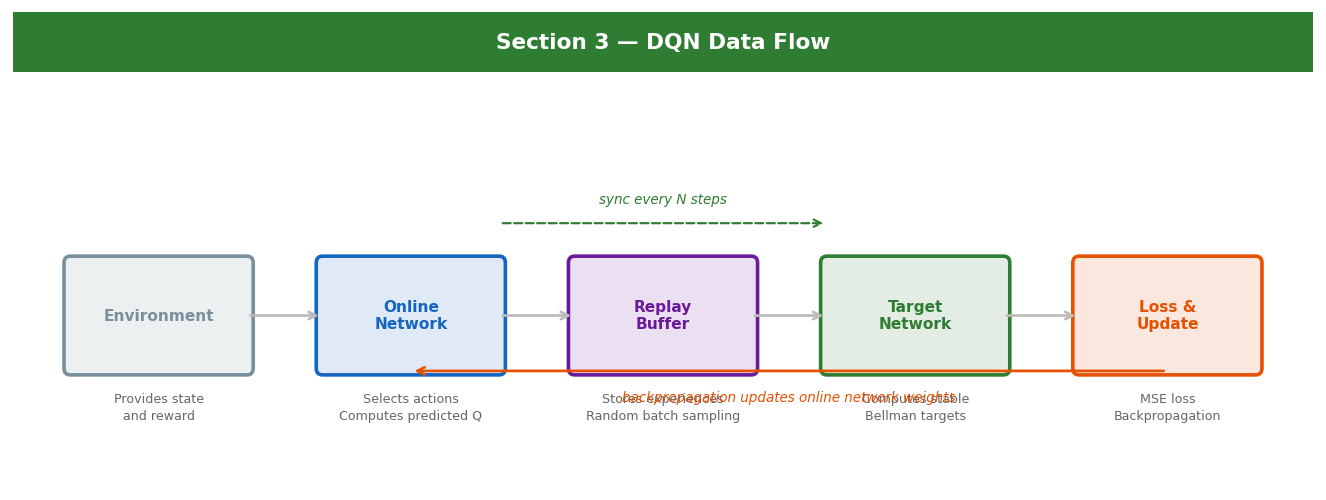

In [ ]:
display(Image(filename='dqn_assets/dqn_architecture.png'))

In [ ]:
# DQN architecture — data flow (pseudocode)
state = env.observe()

# Online network predicts Q-values
q_values = online_network.forward(state)      # e.g. [0.3, 0.8, -0.1, 0.5]

# ε-greedy action selection
if random.random() < epsilon:
    action = random.randint(0, num_actions - 1)  # explore
else:
    action = np.argmax(q_values)                  # exploit

# Step environment
next_state, reward, done = env.step(action)

# Store experience in replay buffer
replay_buffer.append((state, action, reward, next_state, done))

# Sample a random batch and train
batch = random.sample(replay_buffer, batch_size)
train_on_batch(online_network, target_network, batch)
print("DQN data flow: State → Online Net → Action → Env → Buffer → Train")


DQN data flow: State → Online Net → Action → Env → Buffer → Train


In [ ]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> DQN has three main components: the <strong>online network</strong> (trained every step), the <strong>replay buffer</strong> (stores experiences), and the <strong>target network</strong> (provides stable training targets). The interaction between these three is what makes DQN stable enough to solve complex problems.</div>'''))

<div style="background:#6a1b9a;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">4</span><span style="font-size:16px;font-weight:600;color:white;">Experience Replay</span></div>


## Section 4 — Experience Replay

If we trained the network immediately on each experience — like Q-Learning updates the table — we would have a problem.
Consecutive experiences are **highly correlated**: step 1, step 2, step 3 all come from the same region in sequence.
Training on correlated data causes **catastrophic forgetting** of earlier experiences.

**Solution:** Store every experience in a large circular **replay buffer**.
During training, draw a **random batch** — this breaks the correlations and allows experiences to be reused.


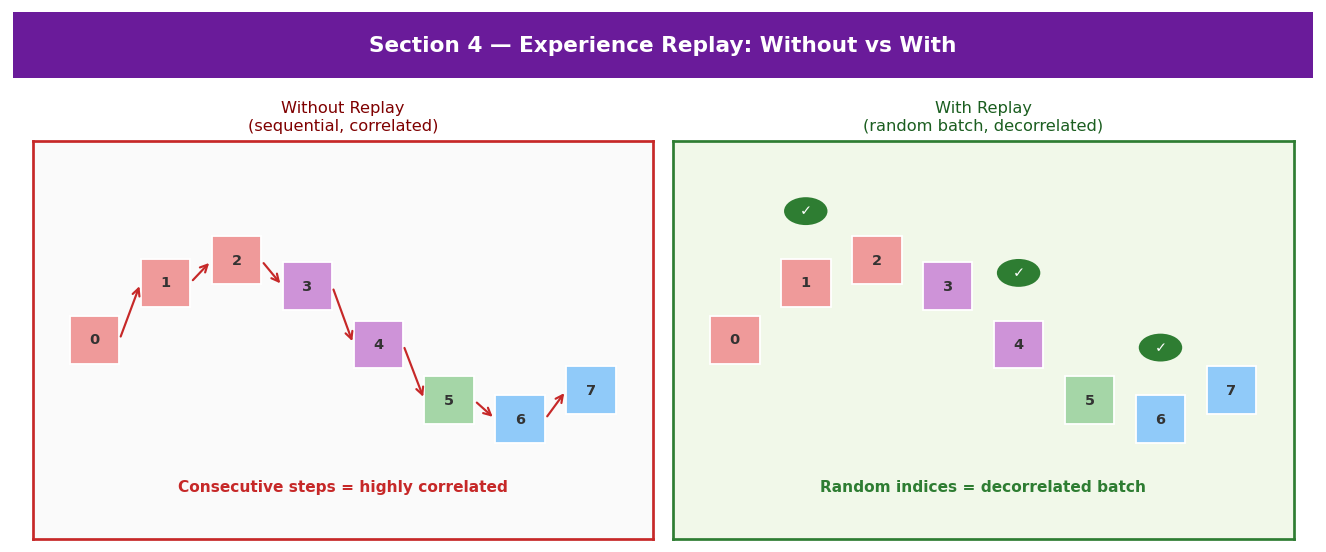

In [ ]:
display(Image(filename='dqn_assets/experience_replay.png'))

In [ ]:
from collections import deque

class ReplayBuffer:
    """
    Circular buffer storing (s, a, r, s', done) tuples.
    When full, oldest experiences are overwritten.
    """
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Return a random batch — breaks temporal correlations."""
        return random.sample(self.buffer, batch_size)

    def __len__(self):
        return len(self.buffer)

buf = ReplayBuffer(capacity=10_000)
buf.push([0,0], 3, -0.1, [0,1], False)
buf.push([0,1], 1, -0.1, [1,1], False)
buf.push([1,1], 3, 10.0, [1,2], True)

print(f"Buffer size    : {len(buf)}")
print(f"Max capacity   : 10,000")
print(f"Each entry     : (state, action, reward, next_state, done)")
print(f"Sampling       : random.sample(buffer, batch_size)")
print(f"Key property   : indices are random, NOT sequential")


Buffer size    : 3
Max capacity   : 10,000
Each entry     : (state, action, reward, next_state, done)
Sampling       : random.sample(buffer, batch_size)
Key property   : indices are random, NOT sequential


In [ ]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> <strong>Experience replay</strong> stores every (state, action, reward, next state) tuple in a circular buffer. Training samples are drawn randomly rather than used immediately. This breaks temporal correlation, allows experiences to be reused multiple times, and makes training far more stable.</div>'''))

<div style="background:#e65100;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">5</span><span style="font-size:16px;font-weight:600;color:white;">The Target Network</span></div>


## Section 5 — The Target Network

There is a second stability problem. The Bellman target is:

```
target = R + γ × max Q(s′, a′)
```

In DQN the network computes `max Q(s′)` — but the network is being **updated at every step**.
The training target constantly shifts — we are chasing a moving goal.
This causes oscillation, divergence, or failure to converge.

**Solution:** Keep a **second copy** of the network with **frozen weights**.
Use this frozen copy to compute Bellman targets.
Only update its weights periodically (every N steps) by copying from the online network.


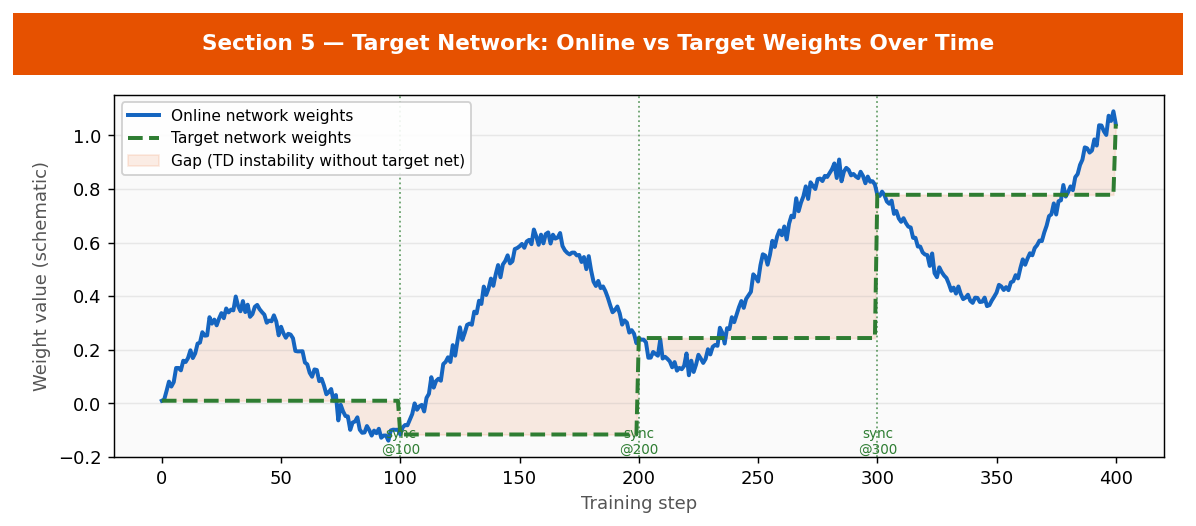

In [ ]:
display(Image(filename='dqn_assets/target_network.png'))

In [ ]:
def compute_targets(batch, online_net, target_net, gamma=0.99):
    """
    Compute Bellman targets using the TARGET network (frozen weights).
    The online network is NOT used here — that is the key difference.
    """
    targets = []
    for state, action, reward, next_state, done in batch:
        if done:
            target = reward                           # terminal: no future
        else:
            next_q  = target_net.forward(next_state) # FROZEN weights
            target  = reward + gamma * np.max(next_q)
        targets.append(target)
    return np.array(targets)

def update_target_network(online_net, target_net):
    """Periodically copy online → target (e.g. every 100 steps)."""
    target_net.weights = online_net.weights.copy()

target_update_freq = 100
print(f"Target network synced every {target_update_freq} steps.")
print(f"Between syncs: target weights are FROZEN.")
print(f"This gives training a stable goal to aim for.")


Target network synced every 100 steps.
Between syncs: target weights are FROZEN.
This gives training a stable goal to aim for.


In [ ]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> The <strong>target network</strong> is a periodically-updated frozen copy of the online network. It provides stable Bellman targets during training. Without it, the training target shifts every step. With it, the agent has a fixed goal for N steps at a time.</div>'''))

<div style="background:#00796b;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">6</span><span style="font-size:16px;font-weight:600;color:white;">The Full DQN Algorithm</span></div>


## Section 6 — The Full DQN Algorithm

All components combined. The full DQN algorithm is Q-Learning with three enhancements:
a **neural network** instead of a table, a **replay buffer** for decorrelated batch training,
and a **target network** for stable Bellman targets.


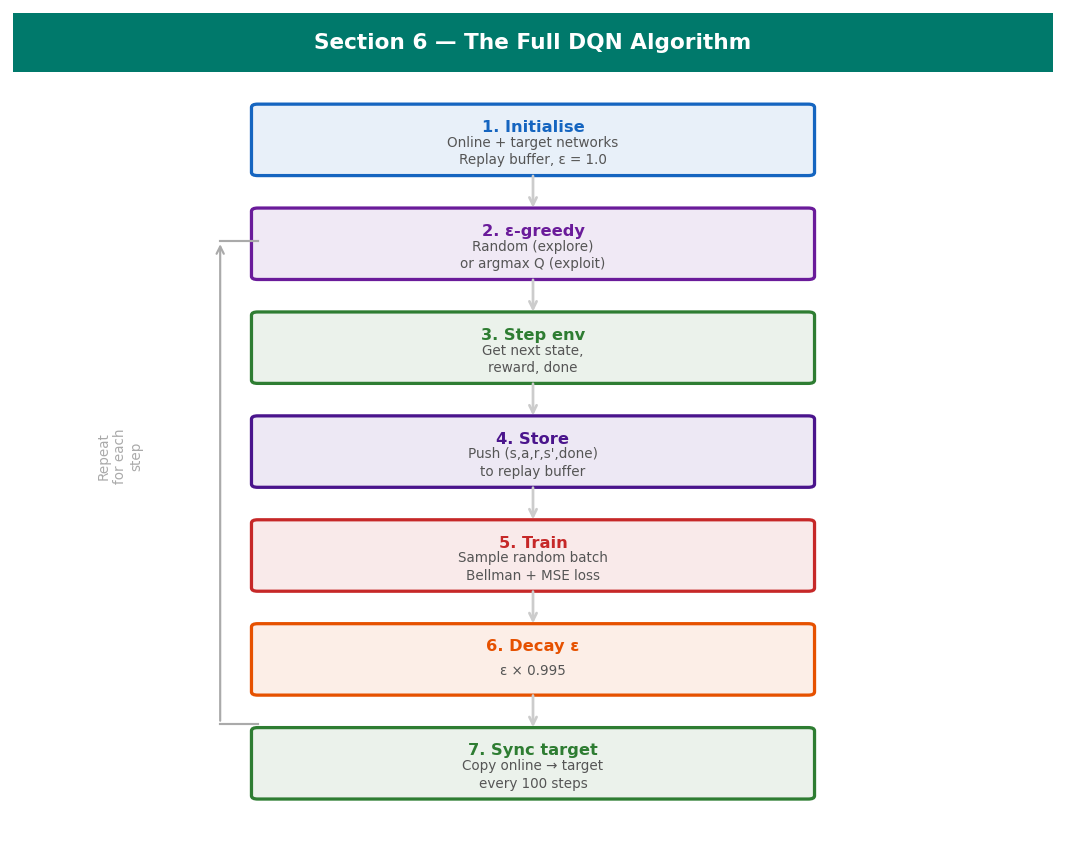

In [ ]:
display(Image(filename='dqn_assets/dqn_algorithm.png'))

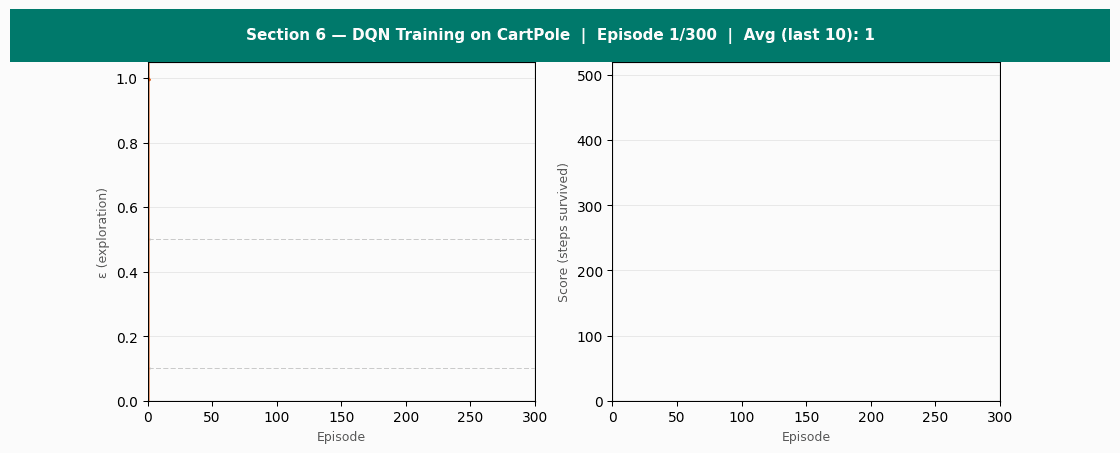

In [ ]:
display(Image(filename='dqn_assets/dqn_training.gif'))

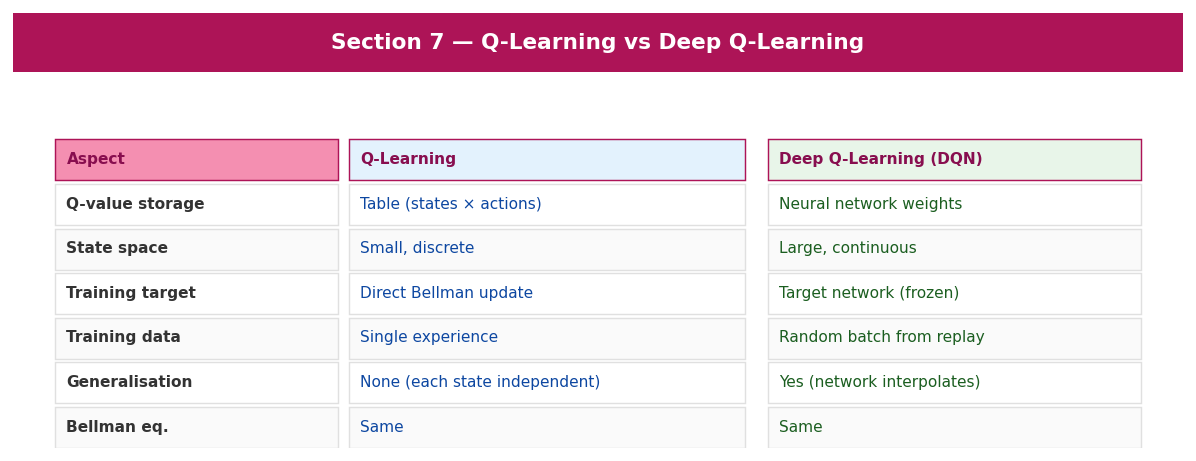

In [ ]:
display(Image(filename='dqn_assets/dqn_vs_qlearning.png'))

In [ ]:
display(HTML('''<div style="background:#f3e5f5;border-left:4px solid #6a1b9a;padding:12px 16px;border-radius:4px;margin:10px 0"><strong style="color:#6a1b9a">Key Takeaway:</strong> The full DQN algorithm is Q-Learning with three enhancements: a <strong>neural network</strong> instead of a table, a <strong>replay buffer</strong> for decorrelated batch training, and a <strong>target network</strong> for stable Bellman targets. The Bellman equation and ε-greedy policy remain unchanged.</div>'''))

<div style="background:#ad1457;padding:14px 20px;border-radius:6px;margin:24px 0 8px;display:flex;align-items:center;gap:14px;"><span style="background:rgba(255,255,255,0.2);border-radius:50%;width:30px;height:30px;display:inline-flex;align-items:center;justify-content:center;font-weight:700;font-size:14px;color:white;">7</span><span style="font-size:16px;font-weight:600;color:white;">Full Python Implementation</span></div>


## Section 7 — Full Python Implementation

Complete, runnable DQN using **PyTorch** on **CartPole-v1**.

```
pip install torch gymnasium numpy
```


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import gymnasium as gym
from collections import deque

# ─── 1. NEURAL NETWORK ───────────────────────────────────────────
class QNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),      nn.ReLU(),
            nn.Linear(hidden, action_size),
        )
    def forward(self, x):
        return self.net(x)

# ─── 2. REPLAY BUFFER ────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buf = deque(maxlen=capacity)
    def push(self, *args):
        self.buf.append(args)
    def sample(self, n):
        return zip(*random.sample(self.buf, n))
    def __len__(self):
        return len(self.buf)

# ─── 3. TRAINING STEP ────────────────────────────────────────────
def train_step(online, target, buf, optimizer, batch_size=32, gamma=0.99):
    states, actions, rewards, next_states, dones = buf.sample(batch_size)
    states      = torch.FloatTensor(np.array(states))
    actions     = torch.LongTensor(actions)
    rewards     = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(np.array(next_states))
    dones       = torch.FloatTensor(dones)

    q_pred   = online(states).gather(1, actions.unsqueeze(1)).squeeze()
    with torch.no_grad():
        q_next   = target(next_states).max(1)[0]
        q_target = rewards + gamma * q_next * (1 - dones)

    loss = nn.MSELoss()(q_pred, q_target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

# ─── 4. MAIN TRAINING LOOP ───────────────────────────────────────
def train_dqn(num_episodes=500):
    env         = gym.make("CartPole-v1")
    state_size  = env.observation_space.shape[0]   # 4
    action_size = env.action_space.n               # 2

    online    = QNetwork(state_size, action_size)
    target    = QNetwork(state_size, action_size)
    target.load_state_dict(online.state_dict())
    optimizer = optim.Adam(online.parameters(), lr=1e-3)
    buf       = ReplayBuffer()
    epsilon   = 1.0
    history   = []

    for ep in range(num_episodes):
        state, _ = env.reset()
        total_reward = 0

        while True:
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    q = online(torch.FloatTensor(state))
                action = q.argmax().item()

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            buf.push(state, action, reward, next_state, float(done))
            state = next_state
            total_reward += reward

            if len(buf) >= 500:
                train_step(online, target, buf, optimizer)

            if done:
                break

        if ep % 10 == 0:
            target.load_state_dict(online.state_dict())

        epsilon = max(0.01, epsilon * 0.995)
        history.append(total_reward)

        if ep % 50 == 0:
            print(f"Episode {ep:>4} | Score: {total_reward:>6.1f} | ε: {epsilon:.3f}")

    return online, history

print("DQN implementation ready.")
print("Run: model, history = train_dqn(num_episodes=500)")


DQN implementation ready.
Run: model, history = train_dqn(num_episodes=500)


---
## Summary

| Concept | What it does |
|---------|-------------|
| **Q-Table limit** | Can only store small discrete state spaces |
| **Neural network** | Approximates Q(s,a) for any state — generalises |
| **Online network** | Trained every step, used to select actions |
| **Replay buffer** | Stores experiences, random sampling breaks correlation |
| **Target network** | Frozen copy, provides stable Bellman targets |
| **Bellman equation** | Unchanged from Q-Learning |
| **ε-greedy** | Unchanged from Q-Learning |

Everything in Q-Learning still applies — DQN is Q-Learning with three engineering improvements that make it scale.

---
*Tutorial produced as part of the ABRHS Research Club workshop series.*
